<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/ML2026_projekt_zaliczeniowy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Wstęp
Projekt był dość wymagający ale zarazem stanowił interesujące wyzwanie. Pierwotnie próbowałem odtworzyć rozwiązanie z opisu zadania, jednak nie byłem w stanie smusić sieci do uczenia się, błąd wychodził zdecydowanie powyżej 5 RMSE. Dlatego zmodyfikowałem zaproponowaną architekturę, a na pewno zmieniłem wiele szczegółów. Ostatecznie, po wielu próbach i analizie zachowania modelu, udało mi się zejść do poziomu około 2.5-2.6 RMSE, i udało mi się osiągność dość dobrą stabilność i odtwarzalność tego rozwiązania, testowanie dodatkowych ziaren losowych nie wprowadziło poprawy ale też nie zaburzyło w znaczący sposób wyniku. Niemniej, podstawowy szkielet architektury zostaje taki sam - konwolucyjny embedding, positional encoding, atencja, klasyfikator prawdopodobieństw z warstw liniowych, i "druga głowa" szacująca offset jako poprawkę.
Miałem też problem z Google Colabem (po paru próbach skończyły się dostępne zasoby obliczeniowe), dlatego musiałem przenieść się na lokalne środowisko więc projekt powstał w Jupyter Labie, i potem zaimportuję go na Colaba żeby go opublikować.
Skupię się na przejściu do końcowego wyniku - dlatego w notatniku znajdują się dwie pary modeli (klasyfikator + offser regressor)

co do komentarzy z rozmiarami tensorów. Dokument jest dość długi, a dodawałem je post factum pisząc podsumowanie. Zatem znajdują się w każdej sekcji forward każdej klasy modeli, ale tylko tam. Mam nadzieję że to wystarczy. Uznałem że ich najważniejszym zadaniem jest pokazać jak zmienia się wymiarowość naszych tokenów przechodzących przez architekturę i myślę, że tą rolę spełniają.

### Funkcje tworzenia zboru danych, zadane jako część treści zadania:


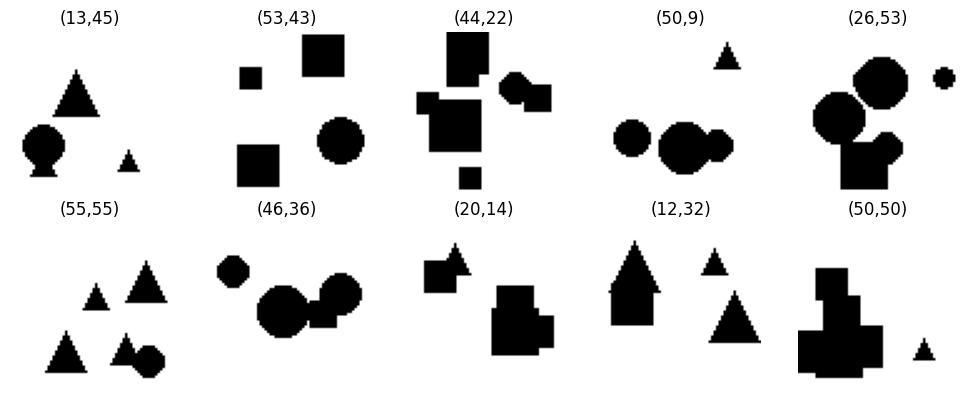

In [ ]:
# ============================================================
# 0. Imports & device
# ============================================================
import torch, random, math, numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch.nn.functional as F


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    """
    Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

    Args:
        num_examples (int): Number of examples to display.
    """
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)

    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
        cx, cy = label.squeeze(0)                       # B=1,2       --> 2
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")

    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")

    plt.tight_layout()
    plt.show()



show_examples()

### Efekt pierwszych iteracji modelu
Tak jak wspomniałem, starałem się odtworzyć zaproponowaną strukturę, ale przy bezpośrednio identycznej parametryzacji nie odniosłem żadnych pozytywnych efektów. Doszedłem do wniosku, że sieć, zwłaszcza część związana z atencją, dostawała zbyt mało istotnych informacji, żeby stabilnie się uczyć i skutecznie zlokalizować inny kształt.
Zdecydowanie pomysł z obliczeniem centrów perception fields z sieci konwolucyjnej i wykorzystywanie go do odtworzenia predykcji sprawdzał się bardzo dobrze i był bardzo ciekawym rozwiązaniem. Myślałem o zmianie architektury embeddingu żeby atencja dostawała więcej lepszych informacji - więcej warstw zwiększyłoby siłę ekspresji sieci konwolucyjnej i atencja dostała by już bardziej dopracowane spostrzeżenia. Jednak dodanie warstw konwolucji zmieniłoby centra i niewykluczone że zaburzyło ich względną strukturę, co mogłoby bardzo kłócić się z ostatecznymi metodamy predykcyji. Ostatecznie zostawiłem tylko jedną warstwę aby zachować interpretowalność tokenów.

Żeby nakarmić głodne informacji głowy atencji (niewielka ale istotna różnica względem głodnej atencji głowy) eksperymentalnie zwiększyłem liczbę kanałów stopniowo aż do 128 (więcej nie pomagało albo szkodziło) dodałem drugą warstwę atencji i dobierałem parametryzację liczby głów atencji. Dostosowałem też rozmiar klasyfikatora do liczby kanałów. Zdecydowanie zwiększyło to model, ale za to nie dość, że się uczył, to jeszcze do tego stabilnie.
Zmiana ziarna losowego niestety nie pomagała, model z klasyfikatorem osiągał około 4-4.3 RMSE ale dodanie offset regressora niestety nie pomgało tak istotnie. tą architekturą nie dałem rady zejść poniżej 3.6 RMSE. Przeszedłem do analizy dlaczego. Aby pokazać proces, efekt pierwszych iteracji pracy nad modelem jest zaimplementowany poniżej
(komentarze o rozmiarach tensorów w części forward każdej klasy):

### Architektura pierwszej części modelu:

In [ ]:
seed = 44  # Ziarno dla wszystkich treningów

In [ ]:
class ConvolutionalEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 128, padding = 0, kernel_size = 20, stride = 4)

    def forward(self, x):
        x = self.conv1(x)     # batch oryginalnych obrazków (B,64,64) -> (B,128,12,12)

        x = x.flatten(2)      #(B,128,12,12) -> (B,128,144)
        x = x.transpose(1,2)  #(B,128,144) -> (B,144,128)
        return x

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, seq_len=144, d_model=128):
        super().__init__()

        pe = torch.zeros(seq_len, d_model)

        position = torch.arange(seq_len).float().unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe.unsqueeze(0) # (B,144,128) -> (B,144,128) nie zmienia kształtu tensora

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):

        attn_out, attn_weights = self.attn(x, x, x)

        x = x + attn_out    # (B,144,128) -> (B,144,128) nie zmienia kształtu tensora
        x = self.norm(x)

        return x, attn_weights

In [ ]:
class MLMscheme(nn.Module):
  def __init__(self, seq_len=144, d_model=128):
      super().__init__()
      self.linear1 = nn.Linear(128, 256)
      self.linear2 = nn.Linear(256, 128)
      self.linear3 = nn.Linear(128,1)
  def forward(self, x):
      x = self.linear1(x) # (B,144,128) -> (B,144,256)
      x = F.relu(x)
      x = self.linear2(x) # (B,144,256) -> (B,144,128)
      x = F.relu(x)
      x = self.linear3(x) # (B,144,128) -> (B,144,1)

      x = x.squeeze(-1)   # (B,144,1) -> (B,144) gdzie to już predykcje prawdopodobieństw na każdym 'receptive field'
      return x

In [ ]:
class OddShapeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = ConvolutionalEmbedding()
        self.position = PositionalEncoding()
        self.attention1 = SelfAttention()
        self.attention2 = SelfAttention()
        self.classifier = MLMscheme()

        # centra 12x12 receptive fields
        centers = []

        for row in range(12):
            for col in range(12):

                x = col * 4 + 10
                y = row * 4 + 10

                centers.append([x, y])

        centers = torch.tensor(centers, dtype=torch.float32)

        self.register_buffer("centers", centers) # ??? -> (144,2)


    def forward(self,x):

        x = self.embedding(x)          # obrazki (B,64,64) -> (B,144,128)
        x = self.position(x)           #(B,144,128) -> (B,144,128)
        x, attn1 = self.attention1(x)  #(B,144,128) -> (B,144,128)
        x, attn2 = self.attention2(x)  #(B,144,128) -> (B,144,128)
        logits = self.classifier(x)    #(B,144,128) -> (B,144)

        probs = torch.softmax(logits, dim=1) #(B,144) -> (B,144)
        prediction = probs @ self.centers    # (B,144) @ (144,2) -> (B,2)

        return prediction, probs, attn2

### Training Loop dla pierwszego modelu, najpierw z jedną głową

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
NVIDIA GeForce RTX 2060


In [ ]:
set_seed(seed)
model = OddShapeNet().to(device)

batch_size = 128
epoch_size = 25000
large_patience = 20 # number of epochs with no improvement to be tolerated

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)
#inicjalizacja zmiennych
criterion = nn.MSELoss()
rmse_values = []
no_improvement_count = 0
epoch = 0
best_rmse = 64

print("Starting training loop...")
while no_improvement_count < large_patience:
    epoch += 1
    # Nowe dane dla każdej epoki
    dataset = OddXYDataset(num_samples=epoch_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.train()
    total_loss = 0
    num_batches = 0
    total_coordinates = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        prediction, probs, attn = model(images)
        loss = criterion(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1


    avg_loss = total_loss / num_batches
    rmse = math.sqrt(avg_loss)

    scheduler.step(rmse)
    rmse_values.append(rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        no_improvement_count = 0
        torch.save(model.state_dict(), "best_onehead.pth")
    else:
        no_improvement_count += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1} | ",
        f"RMSE={rmse:.4f}",
        f"LR={current_lr:.6f} | ",
    )

print(f"Training finished. best rmse = {best_rmse}")

Starting training loop...
Epoch 2 |  RMSE=13.4759 LR=0.001000 | 
Epoch 3 |  RMSE=12.9998 LR=0.001000 | 
Epoch 4 |  RMSE=12.6376 LR=0.001000 | 
Epoch 5 |  RMSE=12.4719 LR=0.001000 | 
Epoch 6 |  RMSE=12.1322 LR=0.001000 | 
Epoch 7 |  RMSE=11.6167 LR=0.001000 | 
Epoch 8 |  RMSE=11.2408 LR=0.001000 | 
Epoch 9 |  RMSE=11.0511 LR=0.001000 | 
Epoch 10 |  RMSE=10.5373 LR=0.001000 | 
Epoch 11 |  RMSE=10.4221 LR=0.001000 | 
Epoch 12 |  RMSE=10.1420 LR=0.001000 | 
Epoch 13 |  RMSE=9.9317 LR=0.001000 | 
Epoch 14 |  RMSE=9.8286 LR=0.001000 | 
Epoch 15 |  RMSE=9.6970 LR=0.001000 | 
Epoch 16 |  RMSE=9.2411 LR=0.001000 | 
Epoch 17 |  RMSE=9.0073 LR=0.001000 | 
Epoch 18 |  RMSE=8.3864 LR=0.001000 | 
Epoch 19 |  RMSE=8.1700 LR=0.001000 | 
Epoch 20 |  RMSE=7.8756 LR=0.001000 | 
Epoch 21 |  RMSE=7.8227 LR=0.001000 | 
Epoch 22 |  RMSE=7.4459 LR=0.001000 | 
Epoch 23 |  RMSE=7.2940 LR=0.001000 | 
Epoch 24 |  RMSE=7.1666 LR=0.001000 | 
Epoch 25 |  RMSE=7.0185 LR=0.001000 | 
Epoch 26 |  RMSE=6.8947 LR=0.001000

### Ewaluacja pierwszej części modelu:
Tworzymy wykres spadku RMSE. Z zaznaczonym poziomem 5 RMSE

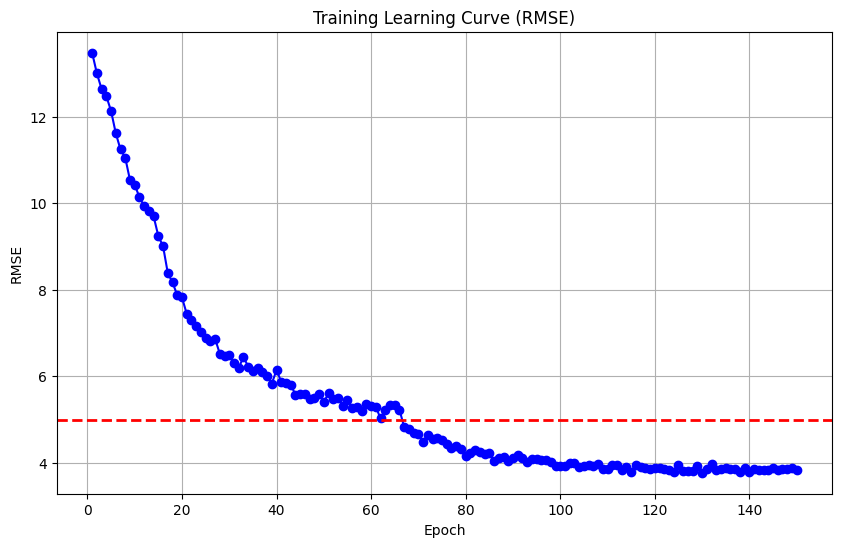

In [ ]:
#Wykres RMSE
epochs = range(1, len(rmse_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, rmse_values, marker='o', linestyle='-', color='b')
# pozioma linia RMSE = 5
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='RMSE = 5')
plt.title('Training Learning Curve (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

3.6 RMSE... not great not terrible

### Zobaczmy jak faktycznie wyglądają predykcje naszego modelu
10 przykładowych obrazków. Czerwony X - prawidłowa odpowiedź. Zielona kropka - predykcja modelu. Dodatkowo heatmapa prawdopodobieństw z klasyfikatora. Analiza przykładów dała dużo wglądu w działanie modelu i konieczność poprawy poszczególnych elementów. Moim zdaniem były kluczowe w poprawianiu modelu.

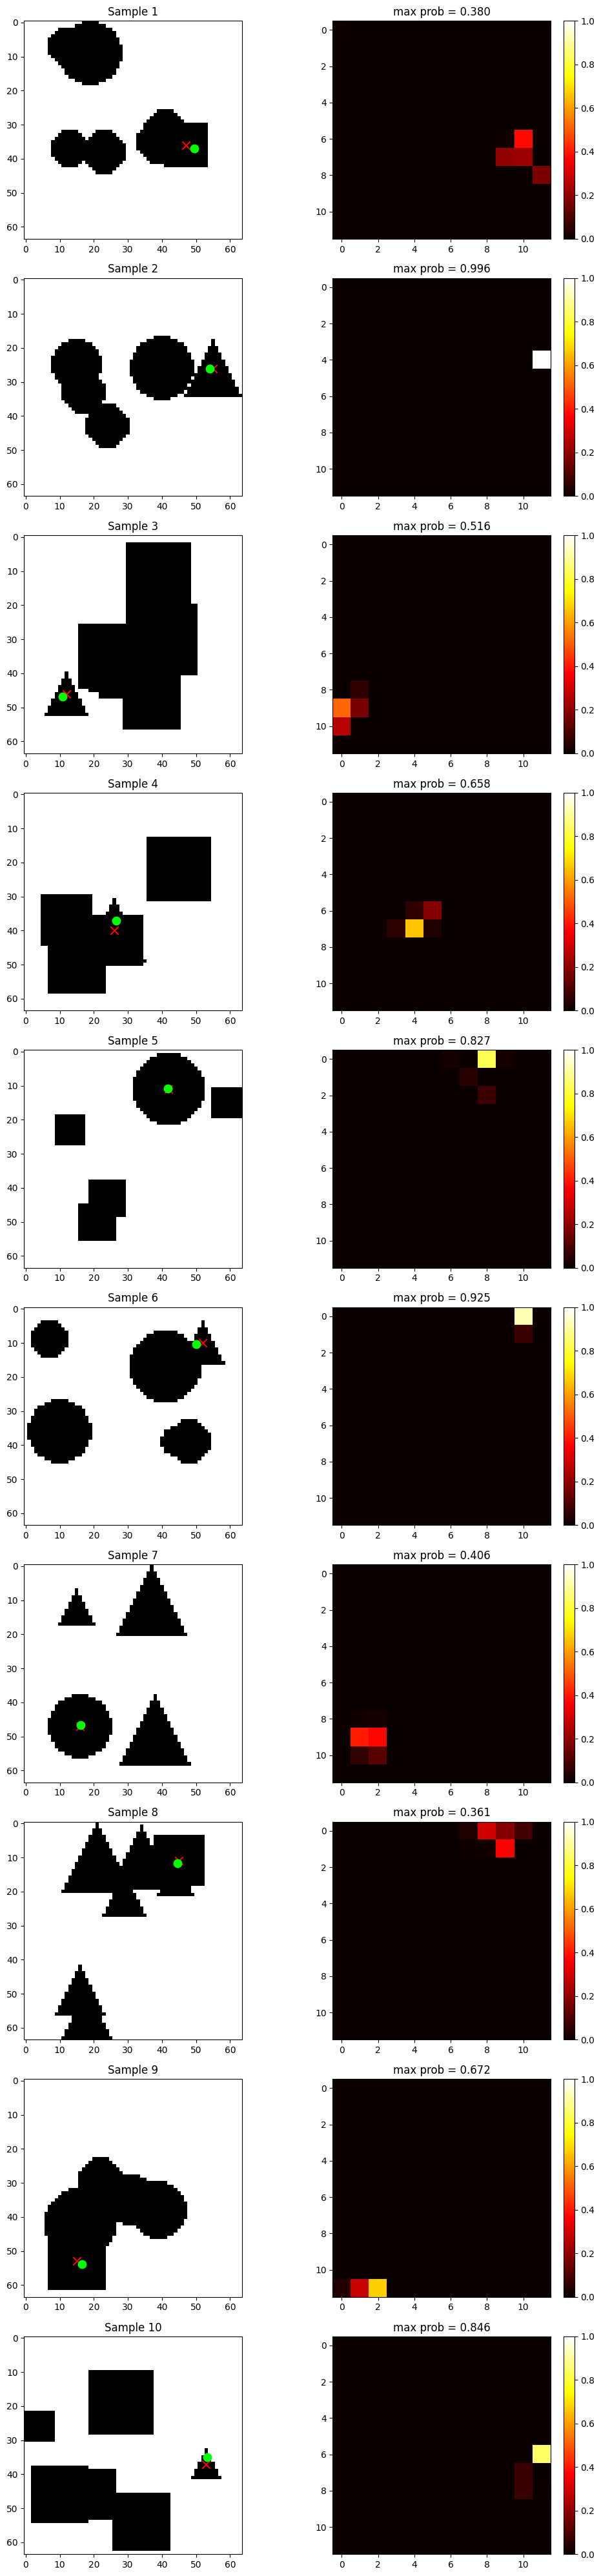

In [ ]:
model.eval()

fig, axes = plt.subplots(10, 2, figsize=(10, 40))

for i in range(10):

    image, label = OddXYDataset(1)[0]

    with torch.no_grad():
        pred, probs, attn2 = model(
            image.unsqueeze(0).to(device)
        )

    prob_map = probs[0].cpu().reshape(12,12)

    # image
    axes[i,0].imshow(image.squeeze(), cmap="gray")

    axes[i,0].scatter(
        label[0],
        label[1],
        c="red",
        marker="x",
        s=80,
        label="true"
    )

    axes[i,0].scatter(
        pred[0,0].cpu(),
        pred[0,1].cpu(),
        c="lime",
        marker="o",
        s=80,
        label="pred"
    )

    axes[i,0].set_title(
        f"Sample {i+1}"
    )

    # probability map
    im = axes[i,1].imshow(
        prob_map,
        cmap="hot",
        vmin=0,
        vmax=1
    )

    axes[i,1].set_title(
        f"max prob = {probs[0].max().item():.3f}"
    )
    plt.colorbar(
      im,
      ax=axes[i,1],
      fraction=0.046,
      pad=0.04
      )

plt.tight_layout()
plt.show()

### Przechodzimy do dalszej części modelu - offset regressor
Podobnie jak w opisanym rozwiązaniu, dodajemy jeszcze jedną sieć lniiową, liczącą poprawkę względem centrum. Tak samo, absolutnie nie uczyły się razem. Ostatecznie osiągnąłem najlepsze wyniki (chociaż tylko marginalnie lepsze. Ale 0.1 RMSE to 0.1 RMSE a karta graficzna musi na siebie zapracować) gdy najpierw uczyłem sam offset regressor przy zamrożonych wagach wczytanych z poprzedniej sieci, a po ~50 epokach douczyłem je razem przy relatywnie niskim learning rate, żeby nie zepsuć już dobrze nauczonej sieci klasyfikującej prawdopodobieństwa receptive fields, ale żeby douczyć do siebie obie głowy i przekazać do offset regressora więcej informacji.  Ważnym okazało się też zainicjowanie ostatniej warstwy z poziomu zero - predykcje które dostawała były już relatywnie dobre a losowe wektory w pierwszych epokach zaburzały proces uczenia. Podobnie, ich predykcje są też ograniczone do przedziału (-10,10). Mają poprawiać działanie sieci gdy jest dość blisko rozwiązania i nie wie gdzie wewnątrz poprawnego receptive field dokładnie znajduje się punkt, a nie próbować uczyć się klasyfikacji całego modelu na nowo, do tego już jest MLMscheme.


In [ ]:
### architektura
class second_head(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(128, 256)
        self.linear2 = nn.Linear(256, 64)
        self.linear3 = nn.Linear(64,2)
        nn.init.zeros_(self.linear3.weight)
        nn.init.zeros_(self.linear3.bias)

    def forward(self, x):
        x = self.linear1(x) #(B,144,128) -> (B,144,256)
        x = F.relu(x)
        x = self.linear2(x) #(B,144,256) -> (B,144,64)
        x = F.relu(x)
        x=self.linear3(x)   #(B,144,64) -> (B,144,2)

        return x

In [ ]:
class Hydra(nn.Module):
    #co dwie głowy to nie jedna czy coś...
    def __init__(self):
        super().__init__()

        self.embedding = ConvolutionalEmbedding()
        self.position = PositionalEncoding()
        self.attention1 = SelfAttention()
        self.attention2 = SelfAttention()
        self.classifier = MLMscheme()
        self.second_head = second_head()

        # centers of the 12x12 receptive fields
        centers = []
        for row in range(12):
            for col in range(12):
                x = col * 4 + 10
                y = row * 4 + 10
                centers.append([x, y])
        centers = torch.tensor(centers, dtype=torch.float32)
        self.register_buffer("centers", centers)
        # (144,2)

    def forward(self,x):

        x = self.embedding(x)          # ??? -> (B,144,128)
        x = self.position(x)           # (B,144,128) -> (B,144,128)
        x, attn1 = self.attention1(x)  # (B,144,128) -> (B,144,128)
        x, attn2 = self.attention2(x)  # (B,144,128) -> (B,144,128)
        logits = self.classifier(x)    # (B,144,128) -> (B,144)
        probs = torch.softmax(logits, dim=1)           # (B,144) -> (B,144)
        offsets = 10 * torch.tanh(self.second_head(x)) # (B,144,128) -> (B,144,2)

        offset_correction = torch.sum(probs.unsqueeze(-1) * offsets, dim=1) # (B,144,2) -> (B,2)

        prediction = (probs @ self.centers + offset_correction) # (B,144) @ (144,2) + (B,2) -> (B,2)

        return prediction, probs, offsets, attn2

In [ ]:
#loading saved single head weights to two headed model
model2 = Hydra().to(device)
one_head_state = torch.load("best_onehead.pth", map_location=device)
missing_keys, unexpected_keys = model2.load_state_dict(one_head_state, strict=False)
print("Successfully loaded pretrained weights.\n")
print("Missing keys (expected: second_head only):")
for k in missing_keys:
    print("  ", k)

print("\nUnexpected keys:")
for k in unexpected_keys:
    print("  ", k)

Successfully loaded pretrained weights.

Missing keys (expected: second_head only):
   second_head.linear1.weight
   second_head.linear1.bias
   second_head.linear2.weight
   second_head.linear2.bias
   second_head.linear3.weight
   second_head.linear3.bias

Unexpected keys:


In [ ]:
set_seed(seed)

batch_size = 128
epoch_size = 25000
large_patience = 20 # number of epochs with no improvement to be tolerated
defrost_time = 50   #pierwsze epoki uczą tylko nową głowę a potem trenujemy resztę

for param in model2.parameters():
    param.requires_grad = False
for param in model2.second_head.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model2.second_head.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

criterion = nn.MSELoss()

rmse_values = []
no_improvement_count = 0
epoch = 0
best_rmse = 64
print("Starting training loop...")
while no_improvement_count < large_patience:
    epoch += 1

    # sprawdzamy czy kurczak już się rozmroził

    if epoch == defrost_time:
        print('defrost')
        for param in model2.parameters():
            param.requires_grad = True

        optimizer = torch.optim.Adam(
            model2.parameters(),
            lr=1e-5
            )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2
        )
        no_improvement_count = 0
        best_rmse = 64

    #po rozmrożeniu

    dataset = OddXYDataset(num_samples=epoch_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model2.train()
    total_loss = 0

    num_batches = 0
    total_coordinates = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        prediction, probs, offsets, attn2 = model2(images)
        loss = criterion(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    rmse = math.sqrt(avg_loss)

    scheduler.step(rmse)
    rmse_values.append(rmse)
    if rmse < best_rmse:
        best_rmse = rmse
        no_improvement_count = 0
        torch.save(model2.state_dict(), "best_twohead.pth")
    else:
        if epoch > defrost_time:
            no_improvement_count += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch} | ",
        f"RMSE={rmse:.4f}",
        f"LR={current_lr:.6f} | ",
    )

print(f"Training finished. best rmse = {best_rmse}")

Starting training loop...
Epoch 1 |  RMSE=3.7982 LR=0.001000 | 
Epoch 2 |  RMSE=3.5812 LR=0.001000 | 
Epoch 3 |  RMSE=3.6307 LR=0.001000 | 
Epoch 4 |  RMSE=3.5650 LR=0.001000 | 
Epoch 5 |  RMSE=3.4784 LR=0.001000 | 
Epoch 6 |  RMSE=3.5412 LR=0.001000 | 
Epoch 7 |  RMSE=3.6289 LR=0.001000 | 
Epoch 8 |  RMSE=3.6436 LR=0.001000 | 
Epoch 9 |  RMSE=3.6036 LR=0.001000 | 
Epoch 10 |  RMSE=3.5685 LR=0.001000 | 
Epoch 11 |  RMSE=3.5780 LR=0.000500 | 
Epoch 12 |  RMSE=3.5688 LR=0.000500 | 
Epoch 13 |  RMSE=3.4871 LR=0.000500 | 
Epoch 14 |  RMSE=3.6141 LR=0.000500 | 
Epoch 15 |  RMSE=3.6808 LR=0.000500 | 
Epoch 16 |  RMSE=3.5533 LR=0.000500 | 
Epoch 17 |  RMSE=3.5675 LR=0.000250 | 
Epoch 18 |  RMSE=3.5487 LR=0.000250 | 
Epoch 19 |  RMSE=3.5870 LR=0.000250 | 
Epoch 20 |  RMSE=3.6288 LR=0.000250 | 
Epoch 21 |  RMSE=3.6546 LR=0.000250 | 
Epoch 22 |  RMSE=3.5264 LR=0.000250 | 
Epoch 23 |  RMSE=3.5756 LR=0.000125 | 
Epoch 24 |  RMSE=3.4833 LR=0.000125 | 
Epoch 25 |  RMSE=3.4961 LR=0.000125 | 
Epoch 26

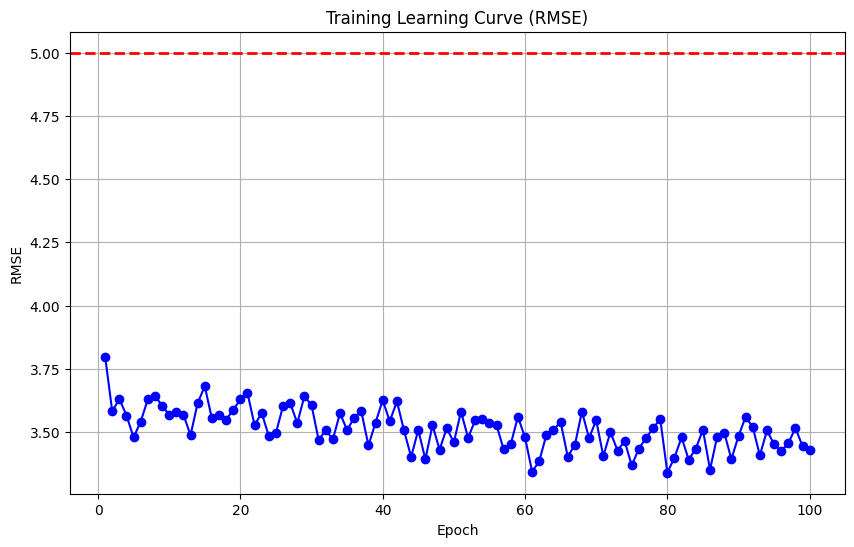

In [ ]:
#Wykres RMSE
epochs = range(1, len(rmse_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, rmse_values, marker='o', linestyle='-', color='b')
# pozioma linia RMSE = 5
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='RMSE = 5')
plt.title('Training Learning Curve (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

### Wizualizujemy i ewaluujemy model
Aby względnić poprawę, niebieską kropką zaznaczone będą predykcje z samych receptieve fields i prawdopodobieństw, niebieska strzałka oznacza poprawkę offset regressora. Zielona kropa to ostateczna predykcja a czerwony X to poprawna odpowiedź

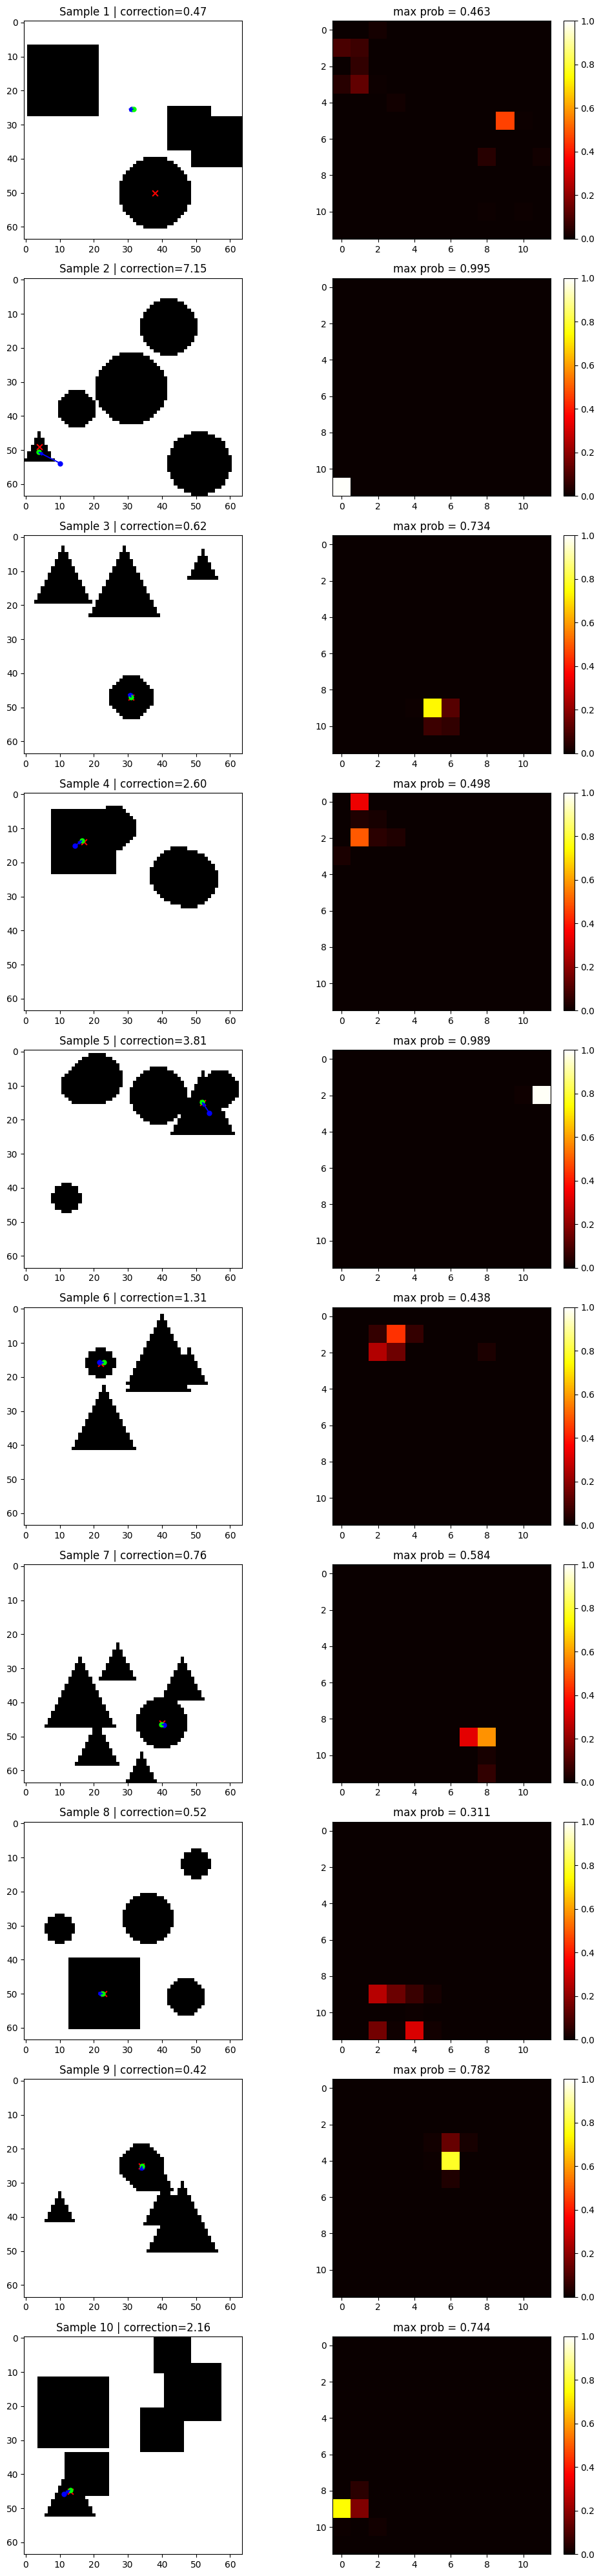

In [ ]:
model2.eval()

model2 = Hydra().to(device)

two_head_state = torch.load(
    "best_twohead.pth",
    map_location=device
)

model2.load_state_dict(two_head_state)

fig, axes = plt.subplots(10, 2, figsize=(10, 40))

for i in range(10):
    image, label = OddXYDataset(1)[0]
    with torch.no_grad():
        pred, probs, offsets, attn2 = model2(image.unsqueeze(0).to(device))

        # soft argmax only
        coarse_pred = probs @ model2.centers

        # offset correction
        correction = torch.sum(probs.unsqueeze(-1) * offsets, dim=1)

    prob_map = probs[0].cpu().reshape(12, 12)

    # ==================================================
    # IMAGE
    # ==================================================

    axes[i,0].imshow(image.squeeze(), cmap="gray")

    # True position (red X)
    axes[i,0].scatter(label[0],label[1],c="red",marker="x",s=40,linewidths=1.5,label="true")

    # Soft-argmax prediction (blue dot)
    axes[i,0].scatter(coarse_pred[0,0].cpu(), coarse_pred[0,1].cpu(), c="blue", marker="o", s=25, label="soft argmax")

    # Final Hydra prediction (green dot)
    axes[i,0].scatter(pred[0,0].cpu(), pred[0,1].cpu(), c="lime", marker="o", s=25, label="final")

    # Arrow showing correction
    axes[i,0].arrow(coarse_pred[0,0].cpu(), coarse_pred[0,1].cpu(), correction[0,0].cpu(), correction[0,1].cpu(), color="blue", width=0.05, head_width=0.8, length_includes_head=True)
    axes[i,0].set_title(f"Sample {i+1} | correction={torch.norm(correction[0]).item():.2f}")

    # ==================================================
    # PROBABILITY MAP
    # ==================================================

    im = axes[i,1].imshow(prob_map,cmap="hot",vmin=0,vmax=1)
    axes[i,1].set_title(f"max prob = {probs[0].max().item():.3f}")
    plt.colorbar(im,ax=axes[i,1],fraction=0.046,pad=0.04)

plt.tight_layout()
plt.show()


### Co poszło nie tak?
widać, że offset regresor się uczy i nawet pomaga. Niebieskie strzałki są "sensowne". Oczywiście, nie są w stanie poprawić źle sklasyfikowanego centrum. RMSE zdecydowanie nie i poprawa tego nie oddaje. Szukamy co jest głównym powodem wysokiego RMSE

Pierwszym pytaniem na które chcemy poznać odpowiedź jest: czy offset regressor się uczy i czy pomaga, a czy jedynie wprowadza dostatecznie mały szum losowy do modelu.
Badamy jego wpływ na predykcję (już nie w terminach RMSE, po prostu odległości) jak i czy strzałki są w odpowiednim kierunku względem poprawnej odpowiedzi - do tego ostatniego zadania jako metrykę użyłem cosine similarity.

Odpowiedzi wskazują, że ewidentnie offset regressor działa. Uczy się i poprawia wyniki w swoim zakresie obowiązków.

In [ ]:
model2.eval()

N = 25000
BATCH_SIZE = 512

dataset = OddXYDataset(N)
loader = DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=False)

improved = 0
worsened = 0

coarse_errors = []
final_errors = []
improvements = []
cosines = []
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(loader):

        images = images.to(device)
        labels = labels.float().to(device)

        pred, probs, offsets, attn2 = model2(images)

        coarse_pred = probs @ model2.centers
        correction = torch.sum(probs.unsqueeze(-1) * offsets, dim=1)
        residual = labels - coarse_pred
        #metryki do obliczenia
        coarse_error = torch.norm(coarse_pred - labels, dim=1)
        final_error = torch.norm(pred - labels,dim=1)
        coarse_errors.extend(coarse_error.cpu().tolist())
        final_errors.extend(final_error.cpu().tolist())
        improvements.extend((coarse_error - final_error).cpu().tolist())
        improved += (final_error < coarse_error).sum().item()
        worsened += (final_error >= coarse_error).sum().item()
        valid = (torch.norm(residual, dim=1) > 1e-6) & (torch.norm(correction, dim=1) > 1e-6)
        if valid.any():
            batch_cos = F.cosine_similarity(residual[valid],correction[valid],dim=1)
            cosines.extend(batch_cos.cpu().tolist())

print("\n" + "=" * 60)

print(f"Mean coarse error : {sum(coarse_errors)/len(coarse_errors):.4f}")
print(f"Mean final error  : {sum(final_errors)/len(final_errors):.4f}")
print(f"Mean improvement  : {sum(improvements)/len(improvements):.4f}")
print(f"\nImproved samples  : {improved} ({100*improved/N:.1f}%)")
print(f"Worsened samples  : {worsened} ({100*worsened/N:.1f}%)")
print(f"\nMean cosine similarity : {sum(cosines)/len(cosines):.4f}")

print("=" * 60)


Mean coarse error : 3.0466
Mean final error  : 1.9887
Mean improvement  : 1.0579

Improved samples  : 21007 (84.0%)
Worsened samples  : 3993 (16.0%)

Mean cosine similarity : 0.7605


### Zatem dlaczego RMSE nie spada poniżej 3?
Szukamy przykładów i dowodów na wysokie RMSE a konkretnie, która część danych odpowiada za dolną granicę, którą jesteśmy w stanie osiągnąć.
Mimo, że pierwsza część modelu osiągnęła zgodne z instrukcjami RMSE, offset regressor nie dał rady go zbić dostatecznie nisko. A widać powyżej, że działa. Ale ewidentnie ma mniejszy wpływ niż powinien więc mimo dowodów jest głównym podejrzanym. Dlaczego?

Zobaczmy co dzieje się w modelu i które przykłady konkretnie sprawiają mu problem.

W szczególności - źle sklasyfikowane centra wymagają poprawy pierwszej części modelu, duży błąd na dobrze zlokalizowanych centrach oznacza, że musimy poprawić offset regressor i nie jest on dostatecznie dobrze zaimplementowany.

90% przypadków w odległości niecałych 4 pixeli!
Wyniki tej komórki ewidentnie wskazują, że za wysokie RMSE nie odpowiada niedokładność wynikająca z ulokowania centrów i nieudolny offset regressor, tylko nieliczna część przypadków, które zostały tragicznie źle sklasyfikowane. Zobaczmy jak one wyglądają

In [ ]:
# ============================================================
# Evaluation
# ============================================================

model2.eval()

dataset = OddXYDataset(num_samples=25000)
loader = DataLoader(dataset, batch_size=256,shuffle=False)

sq_errors = []
distances = []

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)
        pred, probs, offsets, attn2 = model2(images)

        # coordinate errors
        diff = pred - labels

        # squared error per sample
        sample_mse = (diff ** 2).mean(dim=1)
        sq_errors.extend(sample_mse.cpu().numpy())

        # euclidean distance
        dist = torch.norm(diff, dim=1)
        distances.extend(dist.cpu().numpy())

sq_errors = np.array(sq_errors)
distances = np.array(distances)

# ============================================================
# Metrics
# ============================================================

rmse = np.sqrt(sq_errors.mean())

mean_distance = distances.mean()
median_distance = np.median(distances)

p75 = np.percentile(distances, 75)
p90 = np.percentile(distances, 90)
p95 = np.percentile(distances, 95)
p99 = np.percentile(distances, 99)

max_distance = distances.max()

over10 = (distances > 10).sum()
over20 = (distances > 20).sum()

# ============================================================
# Print
# ============================================================

print("=" * 60)

print(f"RMSE             : {rmse:.4f}")
print(f"Mean distance    : {mean_distance:.4f}")
print(f"Median distance  : {median_distance:.4f}")

print(f"\np75              : {p75:.4f}")
print(f"p90              : {p90:.4f}")
print(f"p95              : {p95:.4f}")
print(f"p99              : {p99:.4f}")

print(f"\nMax distance     : {max_distance:.4f}")
print(f">10 px failures  : {over10} ", f"({100*over10/len(distances):.2f}%)")
print(f">20 px failures  : {over20} ", f"({100*over20/len(distances):.2f}%)")
print("=" * 60)

RMSE             : 3.5031
Mean distance    : 2.0477
Median distance  : 0.6023

p75              : 1.4732
p90              : 4.6759
p95              : 10.0441
p99              : 24.9070

Max distance     : 55.8976
>10 px failures  : 1256  (5.02%)
>20 px failures  : 440  (1.76%)


### Wizualizacja porażki
Na początek analiza organoleptyczna: na oko 75% z najgorzej sklasyfikowanych przypadków (w momencie gdy to piszę, dokładny wynik może być seed dependant) to kształt całkowicie rozpoznawalny ulokowany przy brzegu. pozostałe 25% są istotnie trudne lub niewykonalne - kształt jest całkowicie zakryty lub wystaje pojedynczy piksel sugerujący, że coś się dzieje za. Trudne przypadki można zaakceptować, ale zdecydowanie zbyt wiele wygląda jakby nasz model nie widział brzegów. Podstawą do hipotezy może być struktura naszego embeddingu. Odległość centrum receptive field od ramki to co najmniej 10 pixeli, natomiast same centra są relatywnie blisko siebie - co 4 pixele. Ewidentnie edge cases to w tym przypadku dosłownie edge cases...

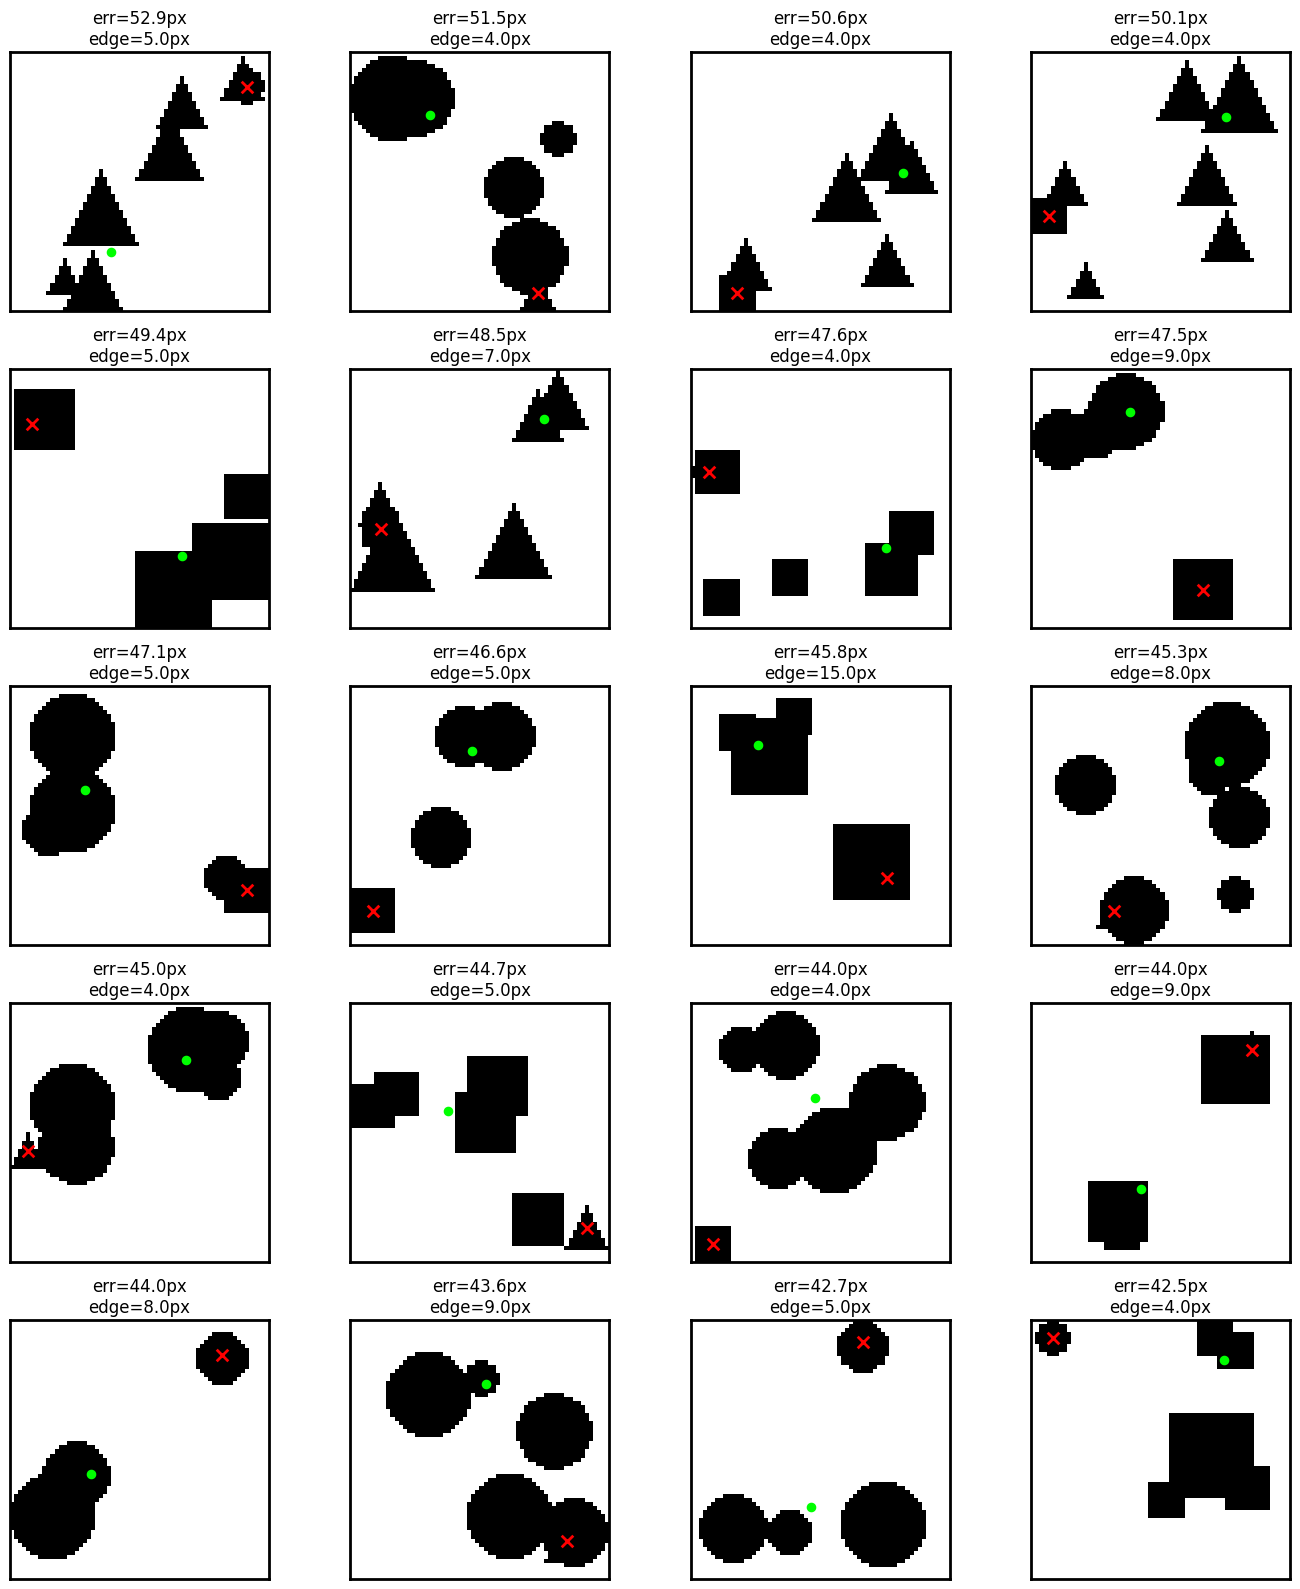


Worst examples

rank | error(px) | nearest edge(px)
------------------------------------
   1 |     52.89 |            5.00
   2 |     51.51 |            4.00
   3 |     50.56 |            4.00
   4 |     50.09 |            4.00
   5 |     49.44 |            5.00
   6 |     48.53 |            7.00
   7 |     47.62 |            4.00
   8 |     47.53 |            9.00
   9 |     47.09 |            5.00
  10 |     46.56 |            5.00
  11 |     45.78 |           15.00
  12 |     45.27 |            8.00
  13 |     45.04 |            4.00
  14 |     44.71 |            5.00
  15 |     43.98 |            4.00
  16 |     43.98 |            9.00
  17 |     43.95 |            8.00
  18 |     43.61 |            9.00
  19 |     42.75 |            5.00
  20 |     42.52 |            4.00


In [ ]:
# ============================================================
# Find worst examples
# ============================================================

model2.eval()

dataset = OddXYDataset(num_samples=25000)
loader = DataLoader(dataset,batch_size=256,shuffle=False)
worst = []

with torch.no_grad():

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        pred, probs, offsets, attn2 = model2(images)
        distances = torch.norm(pred - labels, dim=1)

        for i in range(len(images)):

            x = labels[i, 0].item()
            y = labels[i, 1].item()

            # distance from true target to closest image edge
            edge_dist = min(x, y, 63 - x, 63 - y)
            worst.append((distances[i].item(), edge_dist, images[i].cpu(), labels[i].cpu(), pred[i].cpu()))

# keep only worst 20
worst = sorted(worst, key=lambda x: x[0], reverse=True)[:20]

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(5, 4, figsize=(14, 16))
axes = axes.flatten()

for ax, item in zip(axes, worst):

    distance, edge_dist, image, label, pred = item

    ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
    # true position
    ax.scatter(label[0], label[1], c="red", marker="x", s=70, linewidths=2)

    # prediction
    ax.scatter(pred[0], pred[1], c="lime", marker="o",s=35)

    # visible border
    ax.set_xlim(-0.5, 63.5)
    ax.set_ylim(63.5, -0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    ax.set_title(
        f"err={distance:.1f}px\n"
        f"edge={edge_dist:.1f}px"
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# ============================================================
# Print table
# ============================================================

print("\nWorst examples\n")
print("rank | error(px) | nearest edge(px)")
print("-" * 36)

for i, item in enumerate(worst):

    distance, edge_dist, *_ = item

    print(
        f"{i+1:>4} | "
        f"{distance:>9.2f} | "
        f"{edge_dist:>15.2f}"
    )

### Testowanie hipotezy
Zobaczmy jak to wygląda na większej próbce. Podzielmy dane na klasy względem ich odległości od ramki i zobaczmy jak model radzi sobie z poszczególnymi kategoriami.

Ewidentnie widać różnicę w RMSE i rozkładzie błędu w podziale na kategorie. Zdecydowanie nie radzi sobie z przypadkami bezpośrednio przy brzegu, a problem zanika akurat na wysokości 10 - korelującym z pozycją pierwszego centrum. Nasze perceptrony dobrze "widzą" blisko centrów, ale w oddali nie widzą już prawie nic, a przynajmniej nie jeśli to przy brzegu i nie mają potwierdzenia od pozostałych perceptronów.

In [ ]:
# ============================================================
# Edge-dependent analysis
# ============================================================

model2.eval()

dataset = OddXYDataset(num_samples=50000)

loader = DataLoader(
    dataset,
    batch_size=250,
    shuffle=False
)

groups = {
    "edge < 5": [],
    "5 <= edge < 10": [],
    "10 <= edge < 15": [],
    "edge >= 15": []
}

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        pred, probs, offsets, attn2 = model2(images)

        diff = pred - labels

        # same quantity used during training
        sample_mse = (diff ** 2).mean(dim=1)

        distances = torch.norm(diff, dim=1)

        for i in range(len(labels)):

            x = labels[i, 0].item()
            y = labels[i, 1].item()

            edge_dist = min(x, y, 63 - x, 63 - y)

            entry = (sample_mse[i].item(), distances[i].item())

            if edge_dist < 5: groups["edge < 5"].append(entry)
            elif edge_dist < 10: groups["5 <= edge < 10"].append(entry)
            elif edge_dist < 15: groups["10 <= edge < 15"].append(entry)
            else: groups["edge >= 15"].append(entry)

# ============================================================
# Print statistics
# ============================================================

print("=" * 70)

for name, values in groups.items():

    if len(values) == 0:
        continue

    mse_vals = np.array([v[0] for v in values])
    dist_vals = np.array([v[1] for v in values])

    rmse = np.sqrt(mse_vals.mean())

    print(f"\n{name}")
    print("-" * 70)

    print(f"count         : {len(values)}")
    print(f"RMSE          : {rmse:.4f}")
    print(f"mean distance : {dist_vals.mean():.4f}")
    print(f"median        : {np.median(dist_vals):.4f}")
    print(f"p90           : {np.percentile(dist_vals,90):.4f}")
    print(f"p95           : {np.percentile(dist_vals,95):.4f}")
    print(f"max           : {dist_vals.max():.4f}")

print("\n" + "=" * 70)


edge < 5
----------------------------------------------------------------------
count         : 470
RMSE          : 9.6511
mean distance : 7.7808
median        : 1.9851
p90           : 25.3302
p95           : 33.9761
max           : 58.4443

5 <= edge < 10
----------------------------------------------------------------------
count         : 10159
RMSE          : 4.2342
mean distance : 2.3666
median        : 0.5784
p90           : 5.6655
p95           : 12.8958
max           : 53.3406

10 <= edge < 15
----------------------------------------------------------------------
count         : 15948
RMSE          : 3.1061
mean distance : 1.6633
median        : 0.5096
p90           : 3.1694
p95           : 7.5704
max           : 51.1393

edge >= 15
----------------------------------------------------------------------
count         : 23423
RMSE          : 2.9730
mean distance : 1.9434
median        : 0.6610
p90           : 4.7294
p95           : 8.8832
max           : 41.2453



### ==================================================================================================
### Zmieniamy architekturę przybrzeżną
### ==================================================================================================
Widzimy już, że model nie widzi co się dzieje nad morzem. Żeby to poprawić dodałem padding i dodatkowy rząd perceptronów w sieci konwolucyjnej, aby zbliżyć centrum modelu do brzegu. Zachowując całą poprzednią architekturę i hiperparametry, jedynie dostosowując rozmiar tak aby zmieścił nowe tokeny rozmiaru 192. Ostatecznie to było ostatnim krokiem który pozwolił mi osiągnąć RMSE w okolicach 2.5-2.6, czyli poniżej 3.

In [ ]:
class CoastalConvolutionalEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 128, padding = 4, kernel_size = 20, stride = 4)

    def forward(self, x):
        x = self.conv1(x)     # batch oryginalnych obrazków (B,64,64) -> (B,128,14,14) padding zwiększa liczbę tokenów

        x = x.flatten(2)      #(B,128,14,14) -> (B,16,192)
        x = x.transpose(1,2)  #(B,128,192) -> (B,192,128)
        return x

In [ ]:
class CoastalPositionalEncoding(nn.Module):
    def __init__(self, seq_len=196, d_model=128):
        super().__init__()

        pe = torch.zeros(seq_len, d_model)

        position = torch.arange(seq_len).float().unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe.unsqueeze(0) # (B,192,128) -> (B,192,128) positional encoding nie zmienia wymiarów

In [ ]:
class CoastalSelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):

        attn_out, attn_weights = self.attn(x, x, x)

        x = x + attn_out  # (B,192,128) -> (B,192,128) atencja nie zmienia wymiarów
        x = self.norm(x)  # (B,192,128) -> (B,192,128) normalizacja też nie zmienia wymiarów

        return x, attn_weights

In [ ]:
class CoastalMLMscheme(nn.Module):
  def __init__(self, seq_len=196, d_model=128):
      super().__init__()
      self.linear1 = nn.Linear(128, 256)
      self.linear2 = nn.Linear(256, 128)
      self.linear3 = nn.Linear(128,1)
  def forward(self, x):
      x = self.linear1(x)   # (B,192,128) -> (B,192,256)
      x = F.relu(x)
      x = self.linear2(x)   # (B,192,256) -> (B,192,128)
      x = F.relu(x)
      x = self.linear3(x)   # (B,192,128) -> (B,192,1)

      x = x.squeeze(-1)     # (B,192,1) -> (B,192) gdzie 144 to już predykcje na każdym pikselu
      return x

In [ ]:
class CoastalOddShapeNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = CoastalConvolutionalEmbedding()
        self.position = CoastalPositionalEncoding()
        self.attention1 = CoastalSelfAttention()
        self.attention2 = CoastalSelfAttention()
        self.classifier = CoastalMLMscheme()

        # centers of the 14x14 receptive fields
        centers = []

        for row in range(14):
            for col in range(14):
                x = col * 4 + 6
                y = row * 4 + 6
                centers.append([x, y])
        centers = torch.tensor(centers, dtype=torch.float32)

        self.register_buffer("centers", centers) # ??? -> (192,2)

    def forward(self,x):

        x = self.embedding(x)            # batch oryginalnych obrazków (B,64,64) -> (B,192,128)
        x = self.position(x)             # (B,192,128) -> (B,192,128)
        x, attn1 = self.attention1(x)    # (B,192,128) -> (B,192,128)
        x, attn2 = self.attention2(x)    # (B,192,128) -> (B,192,128)
        logits = self.classifier(x)      # (B,192,128) -> (B,192)
        probs = torch.softmax(logits, dim=1)  # (B,192) -> (B,192)
        prediction = probs @ self.centers     # (B,144) @ (144,2) -> (B,2)

        return prediction, probs, attn2

### Nowy training loop

In [ ]:
set_seed(seed)
coastal_model = CoastalOddShapeNet().to(device)

batch_size = 128
epoch_size = 25000
large_patience = 20 # number of epochs with no improvement to be tolerated

optimizer = torch.optim.Adam(
    coastal_model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

criterion = nn.MSELoss()

rmse_values = []
no_improvement_count = 0
epoch = 0
best_rmse = 64
print("Starting training loop...")
while no_improvement_count < large_patience:
    epoch += 1
    dataset = OddXYDataset(num_samples=epoch_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    coastal_model.train()
    total_loss = 0

    num_batches = 0
    total_coordinates = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        prediction, probs, attn = coastal_model(images)
        loss = criterion(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1


    avg_loss = total_loss / num_batches
    rmse = math.sqrt(avg_loss)

    scheduler.step(rmse)
    rmse_values.append(rmse)
    if rmse < best_rmse:
        best_rmse = rmse
        no_improvement_count = 0
        torch.save(coastal_model.state_dict(), "best_coastal_onehead.pth")
    else:
        no_improvement_count += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1} | ",
        f"RMSE={rmse:.4f}",
        f"LR={current_lr:.6f} | ",
    )

print(f"Training finished. best rmse = {best_rmse}")

Starting training loop...
Epoch 2 |  RMSE=13.2359 LR=0.001000 | 
Epoch 3 |  RMSE=11.8629 LR=0.001000 | 
Epoch 4 |  RMSE=10.6450 LR=0.001000 | 
Epoch 5 |  RMSE=9.6175 LR=0.001000 | 
Epoch 6 |  RMSE=9.1468 LR=0.001000 | 
Epoch 7 |  RMSE=7.9739 LR=0.001000 | 
Epoch 8 |  RMSE=7.2406 LR=0.001000 | 
Epoch 9 |  RMSE=6.5345 LR=0.001000 | 
Epoch 10 |  RMSE=6.4574 LR=0.001000 | 
Epoch 11 |  RMSE=5.9970 LR=0.001000 | 
Epoch 12 |  RMSE=5.9181 LR=0.001000 | 
Epoch 13 |  RMSE=5.4921 LR=0.001000 | 
Epoch 14 |  RMSE=5.4239 LR=0.001000 | 
Epoch 15 |  RMSE=5.3651 LR=0.001000 | 
Epoch 16 |  RMSE=5.2493 LR=0.001000 | 
Epoch 17 |  RMSE=4.9719 LR=0.001000 | 
Epoch 18 |  RMSE=4.8500 LR=0.001000 | 
Epoch 19 |  RMSE=5.0208 LR=0.001000 | 
Epoch 20 |  RMSE=4.7952 LR=0.001000 | 
Epoch 21 |  RMSE=4.8261 LR=0.001000 | 
Epoch 22 |  RMSE=4.7703 LR=0.001000 | 
Epoch 23 |  RMSE=4.4516 LR=0.001000 | 
Epoch 24 |  RMSE=4.7820 LR=0.001000 | 
Epoch 25 |  RMSE=4.6481 LR=0.001000 | 
Epoch 26 |  RMSE=4.4363 LR=0.001000 | 
Epoc

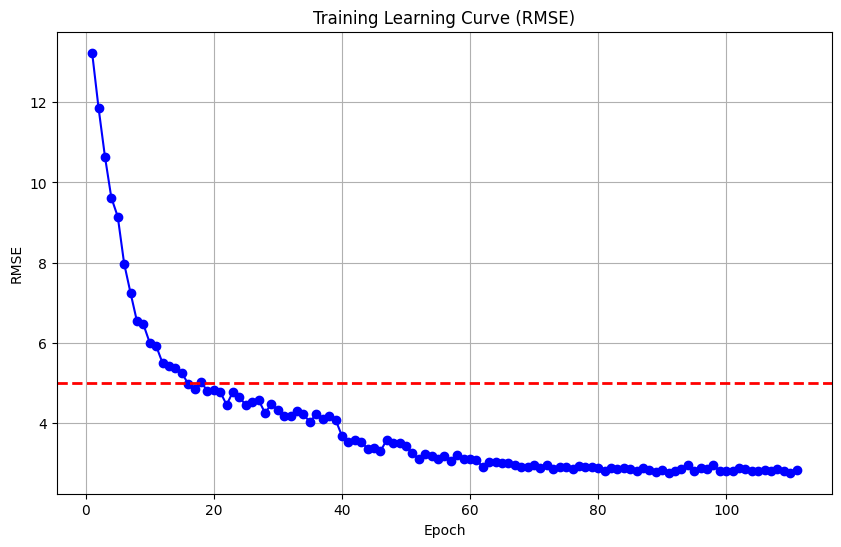

In [ ]:
#Wykres RMSE
epochs = range(1, len(rmse_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, rmse_values, marker='o', linestyle='-', color='b')
# pozioma linia RMSE = 5
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='RMSE = 5')
plt.title('Training Learning Curve (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [ ]:
### architektura drugiej głowy
class Coastalsecond_head(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(128, 256)
        self.linear2 = nn.Linear(256, 64)
        self.linear3 = nn.Linear(64,2)
        nn.init.zeros_(self.linear3.weight)
        nn.init.zeros_(self.linear3.bias)

    def forward(self, x):
        x = self.linear1(x)   # (B,192,128) -> (B,192,256)
        x = F.relu(x)
        x = self.linear2(x)   # (B,192,256) -> (B,192,64)
        x = F.relu(x)
        x=self.linear3(x)     # (B,192,64) -> (B,192,2)

        return x

In [ ]:
class CoastalHydra(nn.Module):
    #co dwie głowy to nie jedna czy coś...
    def __init__(self):
        super().__init__()

        self.embedding = CoastalConvolutionalEmbedding()
        self.position = CoastalPositionalEncoding()
        self.attention1 = CoastalSelfAttention()
        self.attention2 = CoastalSelfAttention()
        self.classifier = CoastalMLMscheme()
        self.second_head = Coastalsecond_head()

        # centers of the 14x14 receptive fields
        centers = []
        for row in range(14):
            for col in range(14):
                x = col * 4 + 6
                y = row * 4 + 6
                centers.append([x, y])
        centers = torch.tensor(centers, dtype=torch.float32)
        self.register_buffer("centers", centers)
        # (144,2)

    def forward(self,x):

        x = self.embedding(x)          # batch oryginalnych obrazków (B,64,64) -> (B,192,128)
        x = self.position(x)           # (B,192,128) -> (B,192,128)
        x, attn1 = self.attention1(x)  # (B,192,128) -> (B,192,128)
        x, attn2 = self.attention2(x)  # (B,192,128) -> (B,192,128)
        logits = self.classifier(x)    # (B,192,128) -> (B,192)
        probs = torch.softmax(logits, dim=1)                       #(B,192) -> (B,192)
        offsets = 10 * torch.tanh(self.second_head(x))             #(B,192,2) -> (B,192,2)
        offset_correction = torch.sum(probs.unsqueeze(-1) * offsets, dim=1)  #(B,2)
        prediction = (probs @ self.centers + offset_correction)    # (B,192) @ (192,2) + (B,2) -> (B,2)

        return prediction, probs, offsets, attn2

In [ ]:
#loading single head weights to two headed model
set_seed(seed)
coastal_model2 = CoastalHydra().to(device)

one_head_state = torch.load("best_coastal_onehead.pth", map_location=device)

missing_keys, unexpected_keys = coastal_model2.load_state_dict(one_head_state, strict=False)

print("Successfully loaded pretrained weights.")
print("\nMissing keys (expected: second_head only):")
for k in missing_keys: print("  ", k)
print("\nUnexpected keys:")
for k in unexpected_keys: print("  ", k)

Successfully loaded pretrained weights.

Missing keys (expected: second_head only):
   second_head.linear1.weight
   second_head.linear1.bias
   second_head.linear2.weight
   second_head.linear2.bias
   second_head.linear3.weight
   second_head.linear3.bias

Unexpected keys:


In [ ]:
set_seed(seed)

batch_size = 128
epoch_size = 25000
large_patience = 20 # number of epochs with no improvement to be tolerated

defrost_time = 50
#pierwsze epoki uczą tylko nową głowę a potem trenujemy resztę
for param in coastal_model2.parameters():
    param.requires_grad = False
for param in coastal_model2.second_head.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    coastal_model2.second_head.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

criterion = nn.MSELoss()

rmse_values = []
no_improvement_count = 0
epoch = 0
best_rmse = 64
print("Starting training loop...")
while no_improvement_count < large_patience:
    epoch += 1

    #sprawdzamy czy kurczak już się rozmroził

    if epoch == defrost_time:
        print('defrost')
        for param in coastal_model2.parameters():
            param.requires_grad = True

        optimizer = torch.optim.Adam(
            model2.parameters(),
            lr=1e-5
            )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2
        )
        no_improvement_count = 0
        best_rmse = 64

    #po rozmrożeniu

    dataset = OddXYDataset(num_samples=epoch_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    coastal_model2.train()
    total_loss = 0

    num_batches = 0
    total_coordinates = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        prediction, probs, offsets, attn2 = coastal_model2(images)
        loss = criterion(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    rmse = math.sqrt(avg_loss)

    scheduler.step(rmse)
    rmse_values.append(rmse)
    if rmse < best_rmse:
        best_rmse = rmse
        no_improvement_count = 0
        torch.save(coastal_model2.state_dict(), "best_coastal_twohead.pth")
    else:
        if epoch > defrost_time:
            no_improvement_count += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch}| ",
        f"RMSE={rmse:.4f}",
        f"LR={current_lr:.6f} | ",
    )

print(f"Training finished. best rmse = {best_rmse}")

Starting training loop...
Epoch 1|  RMSE=2.7131 LR=0.001000 | 
Epoch 2|  RMSE=2.6901 LR=0.001000 | 
Epoch 3|  RMSE=2.6044 LR=0.001000 | 
Epoch 4|  RMSE=2.5792 LR=0.001000 | 
Epoch 5|  RMSE=2.5865 LR=0.001000 | 
Epoch 6|  RMSE=2.6002 LR=0.001000 | 
Epoch 7|  RMSE=2.6317 LR=0.001000 | 
Epoch 8|  RMSE=2.6785 LR=0.001000 | 
Epoch 9|  RMSE=2.7187 LR=0.001000 | 
Epoch 10|  RMSE=2.6879 LR=0.000500 | 
Epoch 11|  RMSE=2.5978 LR=0.000500 | 
Epoch 12|  RMSE=2.6151 LR=0.000500 | 
Epoch 13|  RMSE=2.5092 LR=0.000500 | 
Epoch 14|  RMSE=2.6329 LR=0.000500 | 
Epoch 15|  RMSE=2.6645 LR=0.000500 | 
Epoch 16|  RMSE=2.6201 LR=0.000500 | 
Epoch 17|  RMSE=2.6462 LR=0.000500 | 
Epoch 18|  RMSE=2.5534 LR=0.000500 | 
Epoch 19|  RMSE=2.5598 LR=0.000250 | 
Epoch 20|  RMSE=2.5581 LR=0.000250 | 
Epoch 21|  RMSE=2.6866 LR=0.000250 | 
Epoch 22|  RMSE=2.5748 LR=0.000250 | 
Epoch 23|  RMSE=2.6572 LR=0.000250 | 
Epoch 24|  RMSE=2.5593 LR=0.000250 | 
Epoch 25|  RMSE=2.5542 LR=0.000125 | 
Epoch 26|  RMSE=2.5716 LR=0.00012

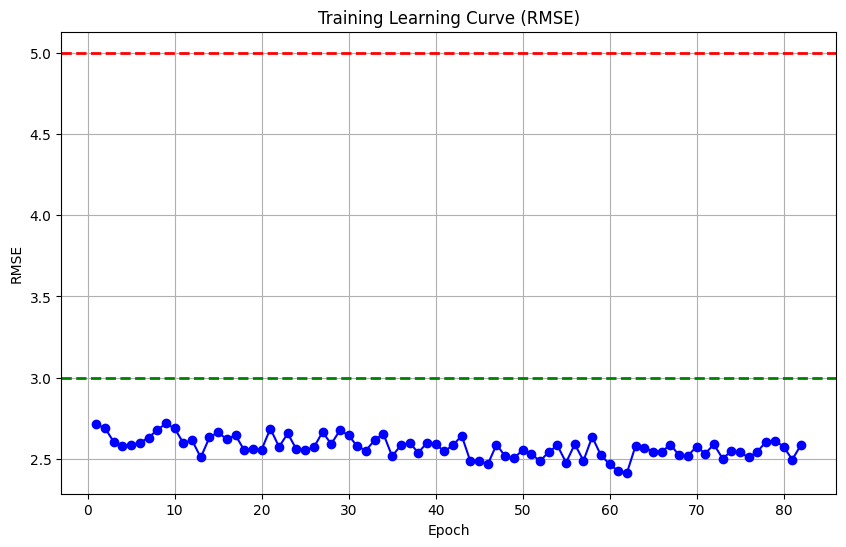

In [ ]:
#Wykres RMSE
epochs = range(1, len(rmse_values) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs, rmse_values, marker='o', linestyle='-', color='b')
# pozioma linia RMSE = 5
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='RMSE = 5')
# pozioma linia bonusu RMSE = 3
plt.axhline(y=3, color='green', linestyle='--', linewidth=2, label='RMSE = 5')
plt.title('Training Learning Curve (RMSE)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# Evaluation
# ============================================================

coastal_model2.eval()

dataset = OddXYDataset(num_samples=25000)
loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=False
)

sq_errors = []
distances = []

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)
        pred, probs, offsets, attn2 = coastal_model2(images)

        # coordinate errors
        diff = pred - labels

        # squared error per sample
        sample_mse = (diff ** 2).mean(dim=1)
        sq_errors.extend(sample_mse.cpu().numpy())

        # euclidean distance
        dist = torch.norm(diff, dim=1)
        distances.extend(dist.cpu().numpy())

sq_errors = np.array(sq_errors)
distances = np.array(distances)

# ============================================================
# Metrics
# ============================================================

rmse = np.sqrt(sq_errors.mean())
mean_distance = distances.mean()
median_distance = np.median(distances)

p75 = np.percentile(distances, 75)
p90 = np.percentile(distances, 90)
p95 = np.percentile(distances, 95)
p99 = np.percentile(distances, 99)

max_distance = distances.max()

over10 = (distances > 10).sum()
over20 = (distances > 20).sum()

# ============================================================
# Print
# ============================================================

print("=" * 60)

print(f"RMSE             : {rmse:.4f}")
print(f"Mean distance    : {mean_distance:.4f}")
print(f"Median distance  : {median_distance:.4f}")

print(f"\np75              : {p75:.4f}")
print(f"p90              : {p90:.4f}")
print(f"p95              : {p95:.4f}")
print(f"p99              : {p99:.4f}")

print(f"\nMax distance     : {max_distance:.4f}")

print(
    f">10 px failures  : {over10} "
    f"({100*over10/len(distances):.2f}%)"
)

print(
    f">20 px failures  : {over20} "
    f"({100*over20/len(distances):.2f}%)"
)

print("=" * 60)

RMSE             : 2.5340
Mean distance    : 1.5331
Median distance  : 0.5766

p75              : 1.2622
p90              : 3.1459
p95              : 6.3713
p99              : 17.5491

Max distance     : 46.7818
>10 px failures  : 723 (2.89%)
>20 px failures  : 181 (0.72%)


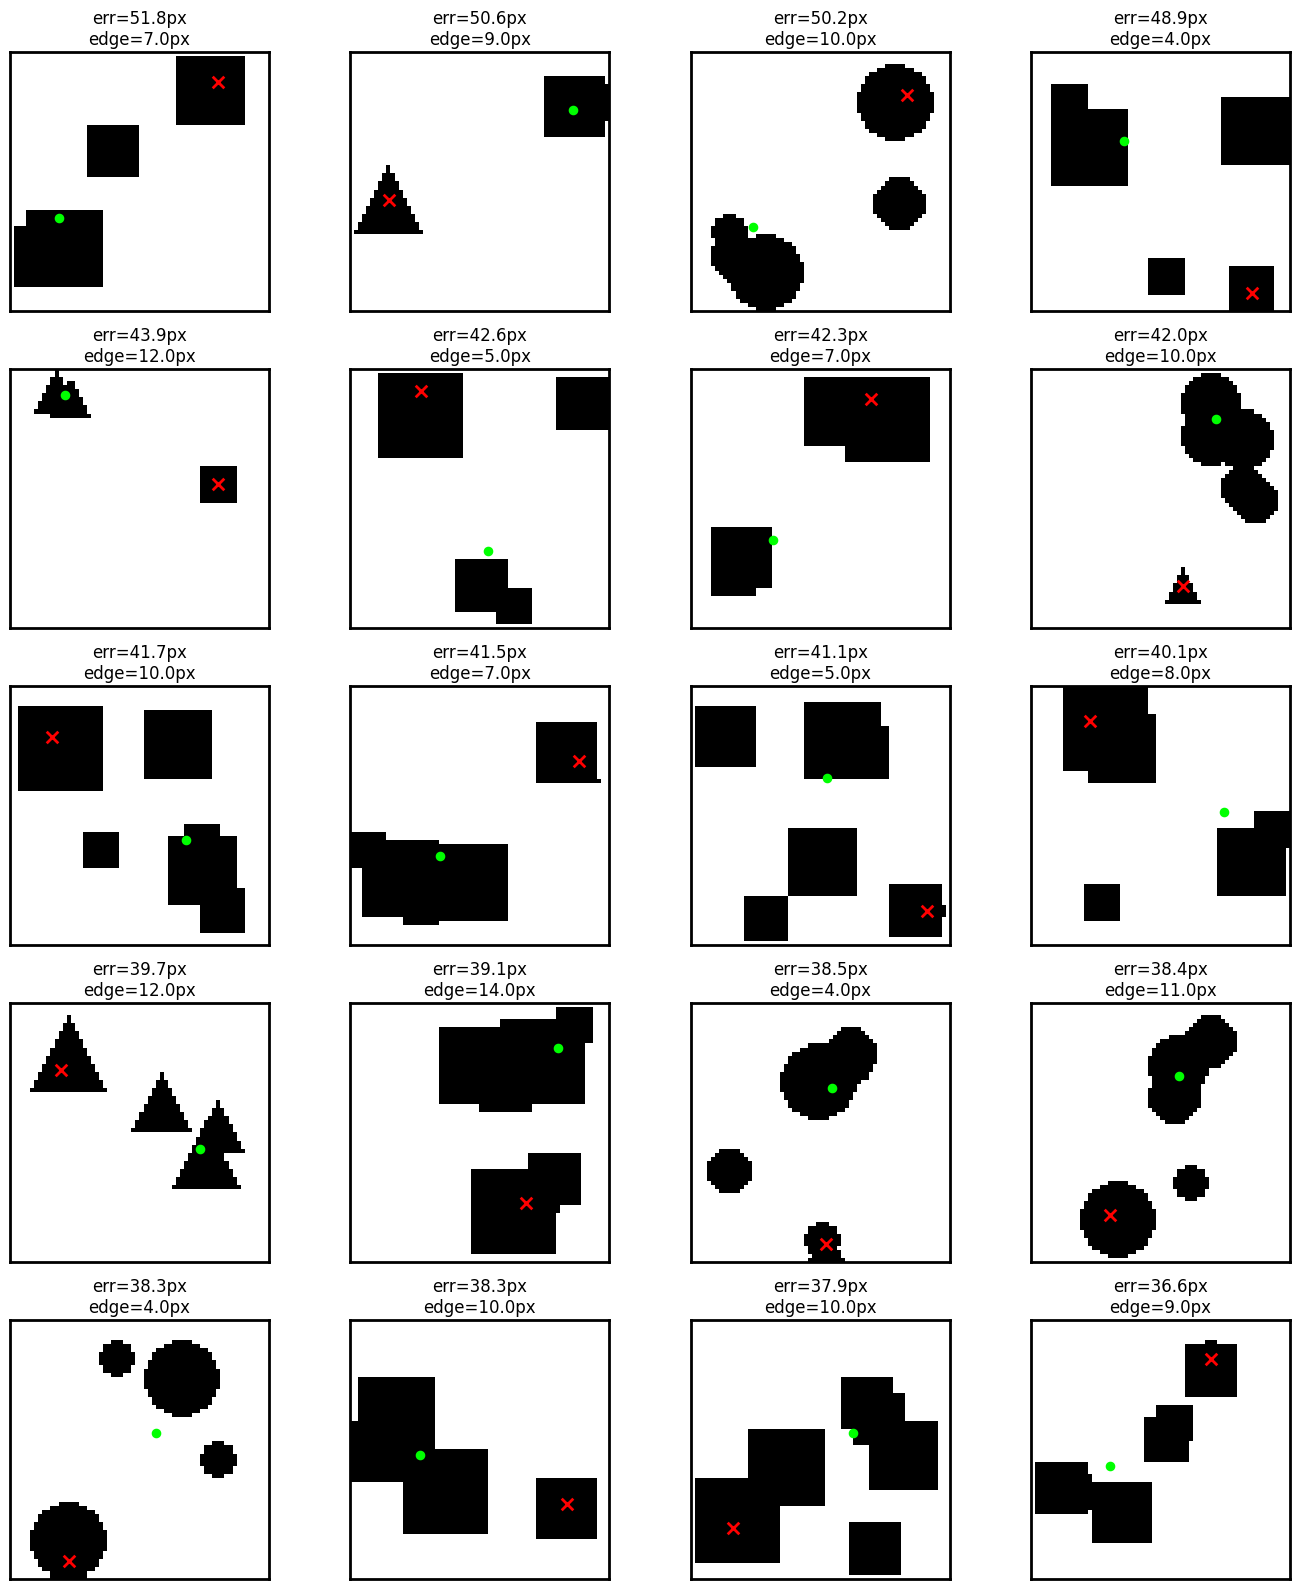

In [ ]:
# ============================================================
# Find worst examples
# ============================================================

coastal_model2.eval()
dataset = OddXYDataset(num_samples=50000)
loader = DataLoader(dataset, batch_size=512, shuffle=False)
worst = []

with torch.no_grad():

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        pred, probs, offsets, attn2 = coastal_model2(images)
        distances = torch.norm(pred - labels, dim=1)
        for i in range(len(images)):
            x = labels[i, 0].item()
            y = labels[i, 1].item()
            # distance from true target to closest image edge
            edge_dist = min(x, y, 63 - x, 63 - y)
            worst.append((distances[i].item(), edge_dist, images[i].cpu(), labels[i].cpu(), pred[i].cpu()))

# keep only worst 20
worst = sorted(worst, key=lambda x: x[0], reverse=True)[:20]

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(5, 4, figsize=(14, 16))
axes = axes.flatten()
for ax, item in zip(axes, worst):
    distance, edge_dist, image, label, pred = item
    ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)

    # true position
    ax.scatter(label[0], label[1], c="red", marker="x", s=70, linewidths=2)

    # prediction
    ax.scatter(pred[0], pred[1], c="lime", marker="o", s=35)
    # visible border
    ax.set_xlim(-0.5, 63.5)
    ax.set_ylim(63.5, -0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)

    ax.set_title(
        f"err={distance:.1f}px\n"
        f"edge={edge_dist:.1f}px"
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### Wstępne podsumowanie eksperymentów
Jak widać, wynik naszego modelu istotnie się poprawił. Ewaluacja na nowych danych dalej utrzymuje poziom RMSE poniżej 3. Poprawiły się błędy w poszczególnych kwantylach. Najbardziej jednak cieszy mnie poprawa "organoleptyczna". Najgorsze wyniki już nie są trywialnie rozpoznawialne, a przynajmniej w znaczącej większości. Widoczność brzegów wyraźnie wzrosła, a model spełnia swoje zadanie, z czego jestem bardzo zadowolony. Na sam koniec przejdźmy do krótkiej analizy zachowania atencji w już wytrenowanym modelu. Przedstawę wykresy predykcji z obrazkiem, i heatmapy prawdopodobieństwa tokenów i atencji z tokenu o najwyższym prawdopodobieństwie.

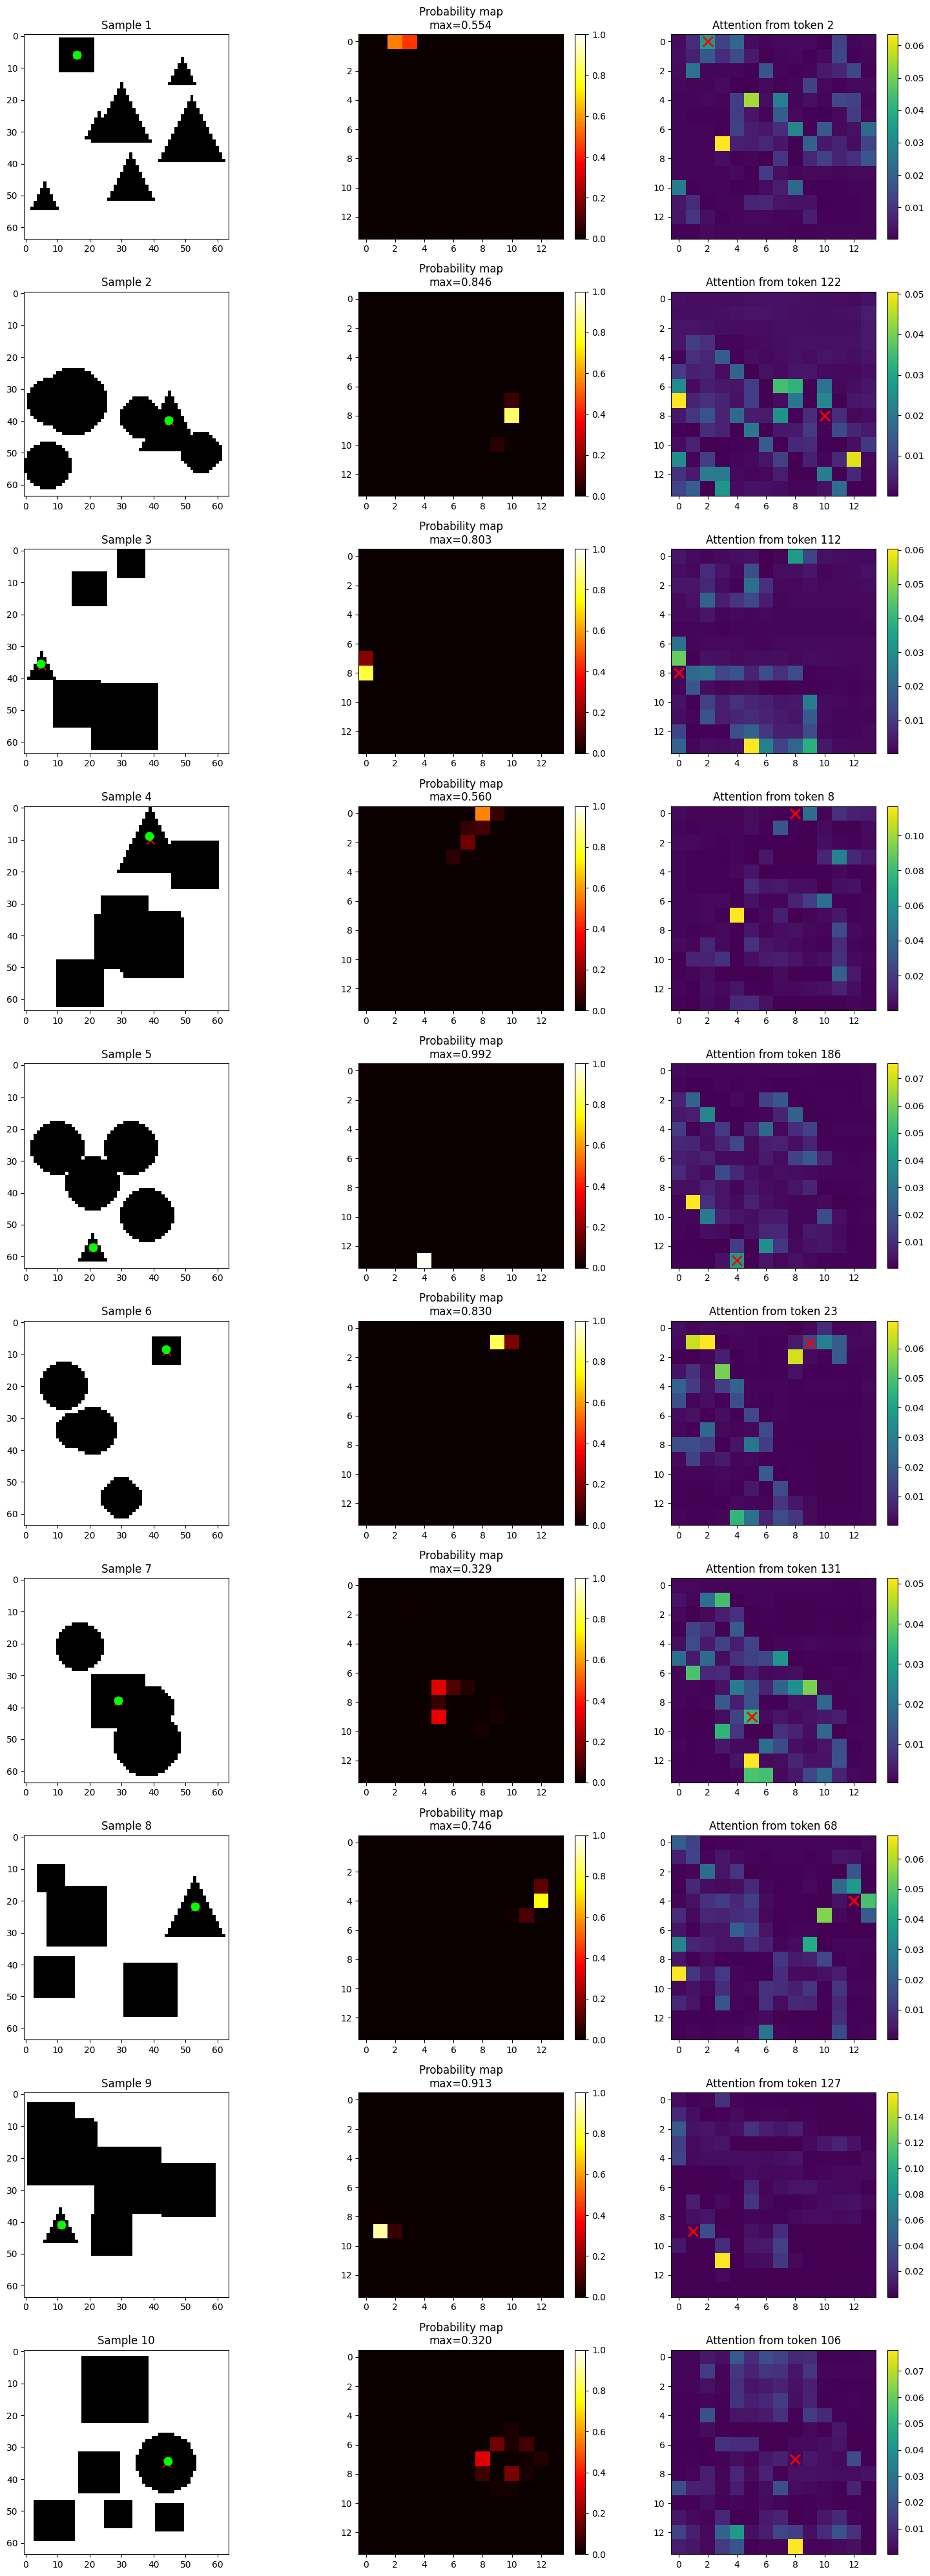

In [ ]:
# ============================================================
# Analiza zachowania modelu:
# predykcja | heatmapa prawdopodobieństwa | atencja z najbardziej prawdopodobnego tokenu
# ============================================================
coastal_model2.eval()
fig, axes = plt.subplots(10, 3, figsize=(15, 40))
for i in range(10):
    image, label = OddXYDataset(1)[0]
    with torch.no_grad():
        pred, probs, offsets, attn2 = coastal_model2(image.unsqueeze(0).to(device))
    # --------------------------------------------------------
    # Probability map
    # --------------------------------------------------------
    prob_map = probs[0].cpu().reshape(14, 14)
    # --------------------------------------------------------
    # Winning token attention map
    # --------------------------------------------------------
    best_token = probs[0].argmax().item()
    attention_row = attn2[0, best_token].cpu()
    attention_map = attention_row.reshape(14, 14)
    row = best_token // 14
    col = best_token % 14
    # --------------------------------------------------------
    # Column 1: image + prediction
    # --------------------------------------------------------
    axes[i, 0].imshow(image.squeeze(), cmap="gray")
    axes[i, 0].scatter(label[0],label[1],c="red", marker="x", s=80, label="true")
    axes[i, 0].scatter(pred[0, 0].cpu(),pred[0, 1].cpu(), c="lime", marker="o",s=80,label="pred")
    axes[i, 0].set_title(f"Sample {i+1}")
    # --------------------------------------------------------
    # Column 2: probability map
    # --------------------------------------------------------
    im_prob = axes[i, 1].imshow(prob_map,cmap="hot",vmin=0, vmax=1)
    axes[i, 1].set_title(f"Probability map\nmax={probs[0].max().item():.3f}")
    plt.colorbar(im_prob, ax=axes[i, 1],fraction=0.046, pad=0.04)
    # --------------------------------------------------------
    # Column 3: attention map
    # --------------------------------------------------------
    im_attn = axes[i, 2].imshow(attention_map, cmap="viridis")
    # mark winning token
    axes[i, 2].scatter(col, row, c="red", marker="x", s=120, linewidths=2)
    axes[i, 2].set_title(f"Attention from token {best_token}")
    plt.colorbar(im_attn, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Analiza wykresu atencji
Popatrzmy jak wyglądają wykresy atencji dla działającego już modelu. Pełna mapa ciepła na 192 tokenach byłaby całkowicie nieczytelna, a przynajmniej mi ciężko byłoby ją interpretować. Dlatego umieściłem wykres atencji wychodzącej z tokenu o najwyższym prawdopodobieństwie jako indykator zachowania atencji modelu. Ten, ułożony w kwadrat 14x14 można już interpretować.

Moje pierwsze ciekawe spostrzeżenie: atencja nie tyle skupia się na centrach kształtów a na ich cechach wyróżniających przy brzegach. Szczególnie dobrze to widać przy dużych kwadratach. Zatem też rozmiar kształtu ma duże znaczenie na kształtowanie się atencji - dla małych, atencja skupia się centralnie na nich i jest bardzo silna w jednym punkcie, który obejmuje brzegi. Dla większych kształtuje się przy brzegach, nasila jeszcze bardziej przy narożnikach a wygasa w środkach. Najbardziej wyróżniają się narożniki kwadratów i trójkątów jak i miejsca gdzie brzegi kształtów się przecinają. Dlatego często najwyższe prawdopodobieństwo przypada w innej komórce niż najwyższa atencja - wystarczy że kształt nie mieści się w całości w tym receptorze i atencja oddala się do innych komórek. Sugeruje to, że warstwa klasyfikacyjna skutecznie przekształca informacje zawarte w reprezentacjach atencji w prawdopodobieństwa lokalizacji obiektu.

Zaskakujące jest też to, że wcale nie wskazuje jednoznacznie okolicy wybranego punktu. Dużo bardziej wygląda jakby zbierała najważniejsze do klasyfikacji fragmenty, z których potem konstruowana jest pozycja faktycznego centrum. Ostatecznie jest to spójne z ideą jej wykorzystania w modelu. Nie stanowi ostatecznego klasyfikatora, natosmiast służy do wzbogacenia i wzmocnienia przekazywanej informacji i tak wygląda to na zaprezentowanych wykresach


### P. S. Dla upewnienia zapisany wynik
po kilku próbach i zmianie środowiska okazało się, że jednak czasami stabilność uczenia się nie jest tak duża jak bym chciał. Poniżej jest załączony fragment wczytujący najlepszy model który udało mi się wytrenować w trakcie pracy nad projektem, wraz z jego ewaluacją na 25000 obrazkach, na wszelki wypadek żeby udowodnić, że ta architektura osiąga RMSE na nowych danych w okolicach 2.6. Jeżeli z collabem coś poszłoby nie tak

In [ ]:
import os
import urllib.request
set_seed(seed)
coastal_model_bestsofar = CoastalHydra().to(device)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Teapot-t/kurs-Uczenie-Maszynowe/main/HydraCoastalBest248.pth",
    "HydraCoastalBestSoFar.pth"
)
saved_state = torch.load("HydraCoastalBestSoFar.pth", map_location=device)

missing_keys, unexpected_keys = coastal_model_bestsofar.load_state_dict(saved_state, strict=False)

print("Successfully loaded pretrained weights.")
print("\nMissing keys (expected: second_head only):")
for k in missing_keys: print("  ", k)
print("\nUnexpected keys:")
for k in unexpected_keys: print("  ", k)

Successfully loaded pretrained weights.

Missing keys (expected: second_head only):

Unexpected keys:


In [ ]:
# ============================================================
# Evaluation
# ============================================================

coastal_model_bestsofar.eval()

dataset = OddXYDataset(num_samples=25000)
loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=False
)

sq_errors = []
distances = []

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)
        pred, probs, offsets, attn2 = coastal_model_bestsofar(images)

        # coordinate errors
        diff = pred - labels

        # squared error per sample
        sample_mse = (diff ** 2).mean(dim=1)
        sq_errors.extend(sample_mse.cpu().numpy())

        # euclidean distance
        dist = torch.norm(diff, dim=1)
        distances.extend(dist.cpu().numpy())

sq_errors = np.array(sq_errors)
distances = np.array(distances)

# ============================================================
# Metrics
# ============================================================

rmse = np.sqrt(sq_errors.mean())
mean_distance = distances.mean()
median_distance = np.median(distances)

p75 = np.percentile(distances, 75)
p90 = np.percentile(distances, 90)
p95 = np.percentile(distances, 95)
p99 = np.percentile(distances, 99)

max_distance = distances.max()

over10 = (distances > 10).sum()
over20 = (distances > 20).sum()

# ============================================================
# Print
# ============================================================

print("=" * 60)

print(f"RMSE             : {rmse:.4f}")
print(f"Mean distance    : {mean_distance:.4f}")
print(f"Median distance  : {median_distance:.4f}")

print(f"\np75              : {p75:.4f}")
print(f"p90              : {p90:.4f}")
print(f"p95              : {p95:.4f}")
print(f"p99              : {p99:.4f}")

print(f"\nMax distance     : {max_distance:.4f}")

print(
    f">10 px failures  : {over10} "
    f"({100*over10/len(distances):.2f}%)"
)

print(
    f">20 px failures  : {over20} "
    f"({100*over20/len(distances):.2f}%)"
)

print("=" * 60)

RMSE             : 2.6804
Mean distance    : 1.5371
Median distance  : 0.5751

p75              : 1.1856
p90              : 2.9077
p95              : 6.2231
p99              : 19.0971

Max distance     : 46.1644
>10 px failures  : 742 (2.97%)
>20 px failures  : 225 (0.90%)
